In [1]:
import os

import matplotlib.pyplot as plt

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["JAX_ENABLE_X64"] = "true"

import numpy as onp
import numpy.typing as npt
import jax
import jax.numpy as jnp
from tqdm import tqdm
from typing import List, Callable

from gridops import set_up_grid_axis, GridAxis1D
from gridops import create_anterpolation_function, make_restriction_function

import sys

sys.path.append("/home/florian/PhD/work/code/msm_for_nn/")

from msmfornn.splines.nesting import compute_J_zeroplus


In [2]:
p = 6
order = p - 1

# Grid charge computation

In [3]:
length = 10.
h = 0.25
n_particles = 25

grid = set_up_grid_axis(length=length, h=h, p=p, periodic=False)

anterpolate = create_anterpolation_function(grid)
jitted_anterpolate = jax.jit(anterpolate)

In [4]:
rng = onp.random.default_rng(12345)
for _ in tqdm(range(100)):
    positions = jnp.array(rng.uniform(0.0, length, size=n_particles))
    charges = jnp.array(rng.uniform(-1., 1., size=n_particles))

    # Call to trigger compilation
    gridcharge, _, _ = jitted_anterpolate(positions, charges)
    # Second call
    gridcharge, _, _ = jitted_anterpolate(positions, charges)

    assert jnp.allclose(gridcharge.sum(), charges.sum())

100%|██████████| 100/100 [00:01<00:00, 90.12it/s]


In [5]:
gridcharge

Array([ 0.00000000e+00, -9.74385969e-04, -3.00482834e-02, -1.31820293e-02,
        3.62665080e-01,  3.16970442e-01,  3.35478400e-02,  6.96742203e-03,
        1.16463749e-01,  2.22269560e-01,  6.53650651e-02,  3.41608491e-02,
        3.24116282e-01,  3.83055399e-01, -2.24589127e-01, -2.81571727e-01,
       -1.00714639e-01, -1.07602574e-01, -1.72396938e-01, -3.42622242e-01,
       -2.58281334e-01, -5.73181077e-02, -2.60852059e-02, -5.50980494e-03,
       -3.45097604e-02, -1.95102980e-01, -1.61638538e-01, -1.79825266e-02,
       -5.34324843e-03, -8.32442669e-02, -4.00926797e-01, -4.47185450e-01,
        5.30419358e-02,  1.71079893e-01, -1.98852509e-01, -5.61167112e-01,
       -2.06042263e-01, -6.98828926e-03,  1.75784966e-02,  1.71083439e-01,
        2.43275165e-01,  3.29224032e-01,  5.01320355e-01,  1.65154815e-01,
        7.36281763e-03,  7.96656388e-07,  0.00000000e+00], dtype=float64)

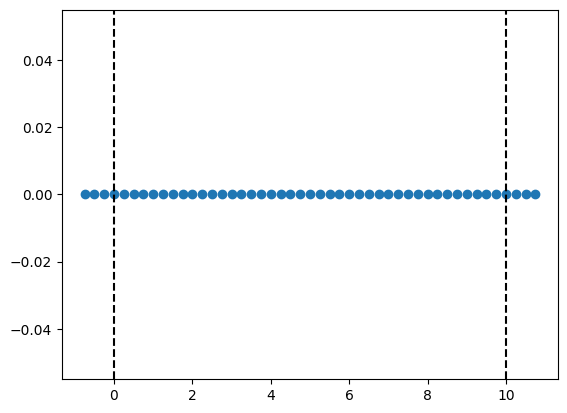

In [6]:
points = (onp.arange(grid.n_total) - p // 2) * grid.h

fig, ax = plt.subplots()
ax.axvline(0, color='k', linestyle='--')
ax.axvline(length, color='k', linestyle='--')
ax.scatter(points, onp.zeros_like(points))


In [7]:
# TODO: compute grid charge for a particle very close to upper domain bound -> I think the grid is currently too small in that case!

pos_appended = jnp.concatenate([positions, jnp.array([10.])])
charges_appended = jnp.concatenate([charges, jnp.array([0.6])])
gc, _, _ = anterpolate(pos_appended, charges_appended)

assert jnp.allclose(gc.sum(), charges_appended.sum())

In [8]:
gc = grid.get_gridindices_and_splinevals(jnp.array([10.]))
gc

(Array([40, 41, 42, 43, 44, 45], dtype=int64),
 Array([0.        , 0.00833333, 0.21666667, 0.55      , 0.21666667,
        0.00833333], dtype=float64))

In [9]:
gc = grid.get_gridindices_and_splinevals(jnp.array([10. - 1.e-6]))
gc

(Array([40, 41, 42, 43, 44, 45], dtype=int64),
 Array([8.53333330e-30, 8.33350000e-03, 2.16668333e-01, 5.50000000e-01,
        2.16665000e-01, 8.33316667e-03], dtype=float64))

In [10]:
int(onp.ceil(length / h))

40

In [11]:
grid.n_domain

41

In [12]:
grid.length, grid.h

(10.0, 0.25)

# Construction of grids

In [13]:
length = 10.0
max_gridlevel = 4

grids_all_levels = [None]  # there is no grid at level zero
for l in range(1, max_gridlevel + 1):
    h = length / (2 ** (max_gridlevel - l))
    print(l, h)
    grid = set_up_grid_axis(length=length, h=h, p=p, periodic=False)
    grids_all_levels.append(grid)

1 1.25
2 2.5
3 5.0
4 10.0


In [14]:
grids_all_levels

[None,
 GridAxis1D(periodic=False, length=10.0, h=1.25, n_domain=9, n_total=15, process_raw_indices=<function set_up_grid_axis.<locals>.process_raw_indices_nonperiodic at 0x7fdc118a8790>, get_gridindices_and_splinevals=<function set_up_grid_axis.<locals>.get_gridindices_and_splinevals at 0x7fdc118a88b0>),
 GridAxis1D(periodic=False, length=10.0, h=2.5, n_domain=5, n_total=11, process_raw_indices=<function set_up_grid_axis.<locals>.process_raw_indices_nonperiodic at 0x7fdc118a8820>, get_gridindices_and_splinevals=<function set_up_grid_axis.<locals>.get_gridindices_and_splinevals at 0x7fdc118a89d0>),
 GridAxis1D(periodic=False, length=10.0, h=5.0, n_domain=3, n_total=9, process_raw_indices=<function set_up_grid_axis.<locals>.process_raw_indices_nonperiodic at 0x7fdc118a8940>, get_gridindices_and_splinevals=<function set_up_grid_axis.<locals>.get_gridindices_and_splinevals at 0x7fdc118a8310>),
 GridAxis1D(periodic=False, length=10.0, h=10.0, n_domain=2, n_total=8, process_raw_indices=<fun

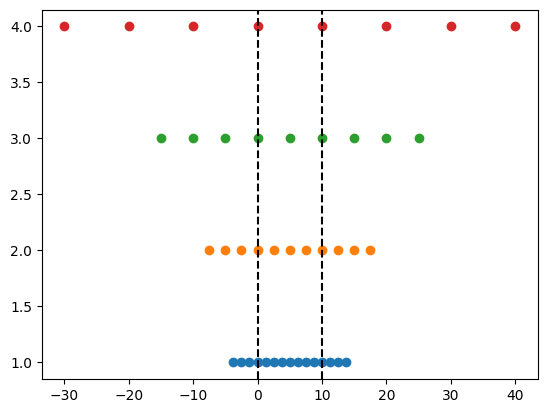

In [15]:
points_all_levels = [None]

fig, ax = plt.subplots()
ax.axvline(0, color='k', linestyle='--')
ax.axvline(length, color='k', linestyle='--')

for l, g in enumerate(grids_all_levels):
    if l == 0:
        continue
    points = (onp.arange(g.n_total) - p // 2) * g.h
    points_all_levels.append(points)
    ax.scatter(points, onp.zeros_like(points) + l)


In [16]:
def shift(m: npt.ArrayLike):
    return m - p // 2


def unshift(m: int):
    return m + p // 2

In [17]:
m_raw = 2
n_raw = shift(onp.arange(len(points_all_levels[1])))

In [18]:
n_raw

array([-3, -2, -1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [19]:
onp.abs(n_raw - 2 * m_raw)

array([7, 6, 5, 4, 3, 2, 1, 0, 1, 2, 3, 4, 5, 6, 7])

In [20]:
onp.abs(n_raw - 2 * m_raw) <= p // 2

array([False, False, False, False,  True,  True,  True,  True,  True,
        True,  True, False, False, False, False])

In [21]:
onp.where(onp.abs(n_raw - 2 * m_raw) <= p // 2)[0]

array([ 4,  5,  6,  7,  8,  9, 10])

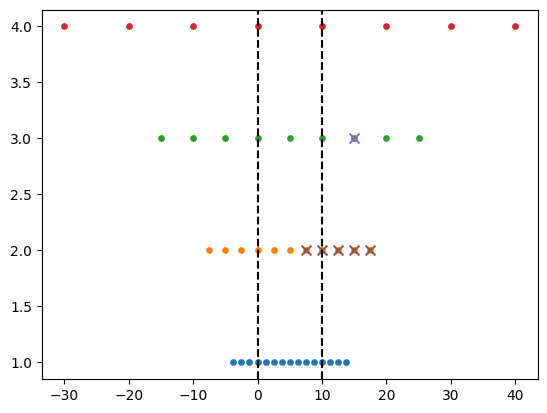

In [22]:
fig, ax = plt.subplots()
ax.axvline(0, color='k', linestyle='--')
ax.axvline(length, color='k', linestyle='--')

for l in range(1, max_gridlevel + 1):
    g = grids_all_levels[l]
    points = points_all_levels[l]
    ax.scatter(points, onp.full_like(points, l), s=15)

l = 3
m_raw = 3
n_raw = shift(onp.arange(len(points_all_levels[l - 1])))
is_in_bounds = onp.where(onp.abs(n_raw - 2 * m_raw) <= p // 2)
n_raw_selected = n_raw[is_in_bounds]

ax.scatter(points_all_levels[l][unshift(m_raw)], l, marker="x", s=50)
ax.scatter(points_all_levels[l - 1][unshift(n_raw_selected)],
           onp.full_like(n_raw_selected, l - 1), marker="x", s=50)

# Restriction

In [23]:
J_zeroplus = compute_J_zeroplus(p)
J = onp.concatenate((J_zeroplus[::-1][:-1], J_zeroplus))
J

array([0.03125, 0.1875 , 0.46875, 0.625  , 0.46875, 0.1875 , 0.03125])

In [24]:
n_particles = 15

rng = onp.random.default_rng(8439293)
xs = rng.uniform(0., length, size=n_particles)
qs = rng.uniform(-1., 1., size=n_particles)

## Compare grid charges computed via restriction with directly computed ones

In [25]:
anterpolation_funcs_all_levels = [None] + [jax.jit(create_anterpolation_function(g)) for g in grids_all_levels[1:]]

restriction_funcs_all_levels = [None, None]
for l in range(2, len(grids_all_levels)):
    rf = make_restriction_function(grids_all_levels[l], grids_all_levels[l - 1], J)
    rf = jax.jit(rf)
    restriction_funcs_all_levels.append(rf)

In [26]:
gridcharges_direct = [None] + [af(xs, qs)[0] for af in anterpolation_funcs_all_levels[1:]]

gridcharges_via_restriction = [None, None]
for l in range(2, len(grids_all_levels)):
    rf = restriction_funcs_all_levels[l]
    gc_lowergrid = gridcharges_direct[l - 1]
    gc = rf(gc_lowergrid)
    gridcharges_via_restriction.append(gc)

In [27]:
gridcharges_direct

[None,
 Array([ 0.00000000e+00,  7.99206745e-03,  2.38020789e-01,  9.45202429e-01,
         1.23204504e+00,  8.99210087e-01,  6.48432624e-01, -2.65156887e-02,
        -8.73304811e-03,  4.39864870e-01, -4.08880742e-01, -4.94877612e-01,
        -6.66595889e-02, -3.68572921e-04,  0.00000000e+00], dtype=float64),
 Array([ 0.00000000e+00,  8.93666229e-03,  3.32294150e-01,  1.47020880e+00,
         1.62289921e+00,  5.60087309e-01, -4.21757004e-04, -4.50075390e-01,
        -1.37044116e-01, -2.15221957e-03,  0.00000000e+00], dtype=float64),
 Array([ 0.        ,  0.01205982,  0.48772805,  1.9420562 ,  1.30796745,
        -0.19040582, -0.14998688, -0.00468617,  0.        ], dtype=float64),
 Array([ 0.        ,  0.01750272,  0.64116943,  2.01739043,  0.80229814,
        -0.06806231, -0.00556575,  0.        ], dtype=float64)]

In [28]:
gridcharges_via_restriction

[None,
 None,
 Array([ 0.00000000e+00,  8.93666229e-03,  3.32294150e-01,  1.47020880e+00,
         1.62289921e+00,  5.60087309e-01, -4.21757004e-04, -4.50075390e-01,
        -1.37044116e-01, -2.15221957e-03,  0.00000000e+00], dtype=float64),
 Array([ 0.        ,  0.01205982,  0.48772805,  1.9420562 ,  1.30796745,
        -0.19040582, -0.14998688, -0.00468617,  0.        ], dtype=float64),
 Array([ 0.        ,  0.01750272,  0.64116943,  2.01739043,  0.80229814,
        -0.06806231, -0.00556575,  0.        ], dtype=float64)]

In [29]:
for gc_direct, gc_restrict in zip(gridcharges_direct[2:], gridcharges_via_restriction[2:]):
    assert jnp.allclose(gc_direct, gc_restrict)

# Test jitting of anterpolation + loop over restriction at all grid levels in single function

In [30]:
def create_anterpolate_and_restrict(grids_all_levels, J: npt.ArrayLike) -> Callable:
    anterpolate = create_anterpolation_function(grids_all_levels[1])
    
    restriction_funcs_all_levels = [None, None]
    for lvl in range(2, len(grids_all_levels)):
        rf = make_restriction_function(grids_all_levels[lvl], grids_all_levels[lvl-1], J)
        restriction_funcs_all_levels.append(rf)
    
    def anterpolate_and_restrict(positions: jax.Array, charges: jax.Array) -> List:
        gridcharge_level_one, _, _ = anterpolate(positions_1d=positions, charges=charges)
        gridcharges_all_levels = [None, gridcharge_level_one]
        for lvl in range(2, len(grids_all_levels)):
            rf = restriction_funcs_all_levels[lvl]
            gc_lowergrid = gridcharges_all_levels[lvl - 1]
            gc = rf(gc_lowergrid)
            gridcharges_all_levels.append(gc)
        
        return gridcharges_all_levels
    
    return anterpolate_and_restrict

In [31]:
anterpolate_and_restrict = create_anterpolate_and_restrict(grids_all_levels, J)
jitted_anterpolate_and_restrict = jax.jit(anterpolate_and_restrict)

In [32]:
jitted_anterpolate_and_restrict(xs, qs)

[None,
 Array([ 0.00000000e+00,  7.99206745e-03,  2.38020789e-01,  9.45202429e-01,
         1.23204504e+00,  8.99210087e-01,  6.48432624e-01, -2.65156887e-02,
        -8.73304811e-03,  4.39864870e-01, -4.08880742e-01, -4.94877612e-01,
        -6.66595889e-02, -3.68572921e-04,  0.00000000e+00], dtype=float64),
 Array([ 0.00000000e+00,  8.93666229e-03,  3.32294150e-01,  1.47020880e+00,
         1.62289921e+00,  5.60087309e-01, -4.21757004e-04, -4.50075390e-01,
        -1.37044116e-01, -2.15221957e-03,  0.00000000e+00], dtype=float64),
 Array([ 0.        ,  0.01205982,  0.48772805,  1.9420562 ,  1.30796745,
        -0.19040582, -0.14998688, -0.00468617,  0.        ], dtype=float64),
 Array([ 0.        ,  0.01750272,  0.64116943,  2.01739043,  0.80229814,
        -0.06806231, -0.00556575,  0.        ], dtype=float64)]

# Prolongation

In [33]:
J

array([0.03125, 0.1875 , 0.46875, 0.625  , 0.46875, 0.1875 , 0.03125])

In [34]:
J_rolled = onp.roll(J, (len(J) - 1) // 2 + 1)

ns_raw = jnp.arange(-10, 15)

for m_raw in range(0, 10):
    m_minus_2n = m_raw - 2 * ns_raw
    cond = jnp.abs(m_minus_2n) <= p / 2
    inds_into_J = m_minus_2n[cond]
    print(m_raw, cond.sum(), inds_into_J, J_rolled[inds_into_J])

0 3 [ 2  0 -2] [0.1875 0.625  0.1875]
1 4 [ 3  1 -1 -3] [0.03125 0.46875 0.46875 0.03125]
2 3 [ 2  0 -2] [0.1875 0.625  0.1875]
3 4 [ 3  1 -1 -3] [0.03125 0.46875 0.46875 0.03125]
4 3 [ 2  0 -2] [0.1875 0.625  0.1875]
5 4 [ 3  1 -1 -3] [0.03125 0.46875 0.46875 0.03125]
6 3 [ 2  0 -2] [0.1875 0.625  0.1875]
7 4 [ 3  1 -1 -3] [0.03125 0.46875 0.46875 0.03125]
8 3 [ 2  0 -2] [0.1875 0.625  0.1875]
9 4 [ 3  1 -1 -3] [0.03125 0.46875 0.46875 0.03125]


In [35]:
def find_raw_ns_by_ceil_floor(m_raw):
    if m_raw % 2 == 0:
        start = int(onp.ceil(onp.round(-p / 4, decimals=1)))
        end = int(onp.floor(onp.round(p / 4, decimals=1)))
    else:
        start = int(onp.ceil(onp.round(0.5 - p / 4, decimals=1)))
        end = int(onp.floor(onp.round(0.5 + p / 4, decimals=1)))
    
    return m_raw // 2 + jnp.arange(start, end + 1)

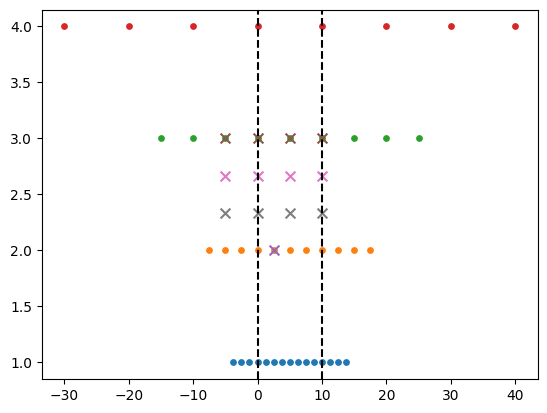

In [36]:
lvl = 2
m_raw = 1

fig, ax = plt.subplots()
ax.axvline(0, color='k', linestyle='--')
ax.axvline(length, color='k', linestyle='--')
for l in range(1, max_gridlevel + 1):
    g = grids_all_levels[l]
    points = points_all_levels[l]
    ax.scatter(points, onp.full_like(points, l), s=15)

ax.scatter(points_all_levels[lvl][unshift(m_raw)], lvl, marker="x", s=50)

# find contributing points by applying comparison
ns_raw = shift(onp.arange(len(points_all_levels[lvl + 1])))
m_minus_2n = m_raw - 2 * ns_raw
cond = jnp.abs(m_minus_2n) <= p // 2
ns_raw_selected = ns_raw[cond]

ax.scatter(points_all_levels[lvl + 1][unshift(ns_raw_selected)],
           onp.full_like(ns_raw_selected, lvl + 1), marker="x", s=50)

# find contributing points by explicit expression
if p % 4 == 0:
    extra = 0
else:
    extra = 1
start = m_raw // 2 - p // 4
end = m_raw // 2 + p // 4
if m_raw % 2 == 0:
    raw_n_range = jnp.arange(start, end + 1)
else:
    raw_n_range = jnp.arange(start + 1 - extra, end + extra + 1)
    
ax.scatter(points_all_levels[lvl + 1][unshift(raw_n_range)],
           onp.full_like(raw_n_range, lvl + 1 - 0.3333, dtype=float), marker="x", s=50)

# find by ceil/floor
raw_ns_by_ceil_floor = find_raw_ns_by_ceil_floor(m_raw)
ax.scatter(points_all_levels[lvl + 1][unshift(raw_ns_by_ceil_floor)],
           onp.full_like(raw_ns_by_ceil_floor, lvl + 1 - 0.6666, dtype=float), marker="x", s=50)

assert onp.array_equal(ns_raw_selected, raw_n_range)
assert onp.array_equal(ns_raw_selected, raw_ns_by_ceil_floor)

# TODO
# m_raw // 2 + jnp.arange(-p // 4, p // 4 + extra + 1)  # or sth like that

In [37]:
raw_n_range

Array([-1,  0,  1,  2], dtype=int64)

In [38]:
m_raw - 2 * raw_n_range

Array([ 3,  1, -1, -3], dtype=int64)

In [39]:
print(f"m = {m_raw}")

if m_raw % 2 == 0:
    print("m even")
    start = int(onp.ceil(onp.round(-p / 4, decimals=1)))
    end = int(onp.floor(onp.round(p / 4, decimals=1)))
else:
    print("m odd")
    start = int(onp.ceil(onp.round(0.5 - p / 4, decimals=1)))
    end = int(onp.floor(onp.round(0.5 + p / 4, decimals=1)))

m_raw // 2 + jnp.arange(start, end + 1)

m = 1
m odd


Array([-1,  0,  1,  2], dtype=int64)

In [40]:
0.5 - p / 4

-1.0

In [41]:
0.5 - (p // 4) - (p % 4) / 4

-1.0

In [42]:
-(p // 4) - ((p % 4) / 4)

-1.5

In [43]:
(-6) // 4

-2

In [44]:
p // 4

1

In [45]:
-p // 4 - (p % 4) / 4, p // 4 + (p % 4) / 4

(-2.5, 1.5)

In [46]:
-p // 4 + 0.5 - (p % 4) // 4, p // 4 + 0.5 + (p % 4) // 4

(-1.5, 1.5)

In [47]:
def create_select_ns(grid: GridAxis1D, p: int):
    if p % 4 == 0:
        p_dependent_shift = 0
    else:
        p_dependent_shift = 1
    
    start_even = -p // 4
    end_even = p // 4
    
    start_odd = -p // 4 - p_dependent_shift + 1 
    end_odd = p // 4 + p_dependent_shift
    
    def select_ns_m_even(m: int):
        m_raw = m - p // 2  # TODO: this should probably be a method of the grid?
        ns_raw = m_raw // 2 + jnp.arange(start_even, end_even + 1)
        return grid.process_raw_indices(ns_raw)
    
    def select_ns_m_odd(m: int):
        m_raw = m - p // 2  # TODO: this should probably be a method of the grid?
        ns_raw = m_raw // 2 + jnp.arange(start_odd, end_odd + 1)
        return grid.process_raw_indices(ns_raw)
    
    return select_ns_m_even, select_ns_m_odd

In [48]:
select_ns_m_even, select_ns_m_odd = create_select_ns(grid=grids_all_levels[lvl], p=p)

In [49]:
select_ns_m_even(0)

Array([-1,  0,  1,  2], dtype=int64)

In [50]:
J

array([0.03125, 0.1875 , 0.46875, 0.625  , 0.46875, 0.1875 , 0.03125])

In [51]:
start = m_raw // 2 - p // 4
end = m_raw // 2 + p // 4

ns_oversized = jnp.arange(start, end + 1)

In [52]:
inds_into_J = m_raw - 2 * ns_oversized

In [53]:
J_rolled[inds_into_J]

array([0.03125, 0.46875, 0.46875])

In [54]:
inds_into_J

Array([ 3,  1, -1], dtype=int64)

In [55]:
intentionally_out_of_bounds_index = len(J)

sanitized_inds_into_J = jnp.where(jnp.abs(inds_into_J) <= p // 2, inds_into_J, intentionally_out_of_bounds_index)

In [56]:
J_rolled[sanitized_inds_into_J]

array([0.03125, 0.46875, 0.46875])

In [57]:
m_raw

1

In [58]:
m_raw / 2 - p / 4, m_raw / 2 + p / 4 

(-1.0, 2.0)

In [59]:
m_raw // 2 - p // 4, m_raw // 2 + p // 4 

(-1, 1)

In [60]:
# even
m_test = 0
jnp.ceil(m_test / 2 - p / 4), jnp.floor(m_test / 2 + p / 4)

(Array(-1., dtype=float64, weak_type=True),
 Array(1., dtype=float64, weak_type=True))

In [61]:
# odd
m_test = 1
jnp.ceil(m_test / 2 - p / 4), jnp.floor(m_test / 2 + p / 4)

(Array(-1., dtype=float64, weak_type=True),
 Array(2., dtype=float64, weak_type=True))

In [62]:
m_raw / 2

0.5

In [63]:
m_raw % 2

1

In [64]:
p_test = 6
m_test = 3

p_extra = (p_test % 4) / 4
m_extra = (m_test % 2) / 2

m_extra, p_extra

(0.5, 0.5)

In [65]:
n_lower_baseline = m_test // 2 - p_test // 4
n_upper_baseline = m_test // 2 + p_test // 4

n_lower_baseline, n_upper_baseline

(0, 2)

In [66]:
shift_lower = m_extra - p_extra
shift_upper =  (m_extra + p_extra)

n_lower_adjusted = n_lower_baseline + shift_lower
n_upper_adjusted = n_upper_baseline + shift_upper

n_lower_adjusted, m_test / 2, n_upper_adjusted

(0.0, 1.5, 3.0)

In [67]:
m_test / 2

1.5

In [68]:
row = onp.zeros(16)
row[:len(J)] = J

In [69]:
matrix = onp.zeros((len(row) // 2,len(row)))

In [70]:
matrix.shape

(8, 16)

In [71]:
for i in range(matrix.shape[0]):
    tmp = onp.roll(row, i)
    matrix[i, :] = tmp

In [72]:
jnp.asarray(matrix.T)

Array([[0.03125, 0.     , 0.     , 0.     , 0.     , 0.     , 0.     ,
        0.     ],
       [0.1875 , 0.03125, 0.     , 0.     , 0.     , 0.     , 0.     ,
        0.     ],
       [0.46875, 0.1875 , 0.03125, 0.     , 0.     , 0.     , 0.     ,
        0.     ],
       [0.625  , 0.46875, 0.1875 , 0.03125, 0.     , 0.     , 0.     ,
        0.     ],
       [0.46875, 0.625  , 0.46875, 0.1875 , 0.03125, 0.     , 0.     ,
        0.     ],
       [0.1875 , 0.46875, 0.625  , 0.46875, 0.1875 , 0.03125, 0.     ,
        0.     ],
       [0.03125, 0.1875 , 0.46875, 0.625  , 0.46875, 0.1875 , 0.03125,
        0.     ],
       [0.     , 0.03125, 0.1875 , 0.46875, 0.625  , 0.46875, 0.1875 ,
        0.03125],
       [0.     , 0.     , 0.03125, 0.1875 , 0.46875, 0.625  , 0.46875,
        0.1875 ],
       [0.     , 0.     , 0.     , 0.03125, 0.1875 , 0.46875, 0.625  ,
        0.46875],
       [0.     , 0.     , 0.     , 0.     , 0.03125, 0.1875 , 0.46875,
        0.625  ],
       [0.     , 0.  

In [73]:
size_1 = len(gridcharges_direct[1])
size_2 = len(gridcharges_direct[2])

In [74]:
I = onp.zeros((size_2, size_1))

In [75]:
def get_entry_of_J(idx):
    if onp.abs(idx) > p // 2:
        return 0.
    else:
        return J_rolled[idx]

In [76]:
for m in range(I.shape[0]):
    for n in range(I.shape[1]):
        I[m, n] = get_entry_of_J(n - 2*m)
        print(f"m = {m}, n = {n}, n-2m = {n - 2 *m}")

m = 0, n = 0, n-2m = 0
m = 0, n = 1, n-2m = 1
m = 0, n = 2, n-2m = 2
m = 0, n = 3, n-2m = 3
m = 0, n = 4, n-2m = 4
m = 0, n = 5, n-2m = 5
m = 0, n = 6, n-2m = 6
m = 0, n = 7, n-2m = 7
m = 0, n = 8, n-2m = 8
m = 0, n = 9, n-2m = 9
m = 0, n = 10, n-2m = 10
m = 0, n = 11, n-2m = 11
m = 0, n = 12, n-2m = 12
m = 0, n = 13, n-2m = 13
m = 0, n = 14, n-2m = 14
m = 1, n = 0, n-2m = -2
m = 1, n = 1, n-2m = -1
m = 1, n = 2, n-2m = 0
m = 1, n = 3, n-2m = 1
m = 1, n = 4, n-2m = 2
m = 1, n = 5, n-2m = 3
m = 1, n = 6, n-2m = 4
m = 1, n = 7, n-2m = 5
m = 1, n = 8, n-2m = 6
m = 1, n = 9, n-2m = 7
m = 1, n = 10, n-2m = 8
m = 1, n = 11, n-2m = 9
m = 1, n = 12, n-2m = 10
m = 1, n = 13, n-2m = 11
m = 1, n = 14, n-2m = 12
m = 2, n = 0, n-2m = -4
m = 2, n = 1, n-2m = -3
m = 2, n = 2, n-2m = -2
m = 2, n = 3, n-2m = -1
m = 2, n = 4, n-2m = 0
m = 2, n = 5, n-2m = 1
m = 2, n = 6, n-2m = 2
m = 2, n = 7, n-2m = 3
m = 2, n = 8, n-2m = 4
m = 2, n = 9, n-2m = 5
m = 2, n = 10, n-2m = 6
m = 2, n = 11, n-2m = 7
m = 2, n

In [77]:
jnp.asarray(I)

Array([[0.625  , 0.46875, 0.1875 , 0.03125, 0.     , 0.     , 0.     ,
        0.     , 0.     , 0.     , 0.     , 0.     , 0.     , 0.     ,
        0.     ],
       [0.1875 , 0.46875, 0.625  , 0.46875, 0.1875 , 0.03125, 0.     ,
        0.     , 0.     , 0.     , 0.     , 0.     , 0.     , 0.     ,
        0.     ],
       [0.     , 0.03125, 0.1875 , 0.46875, 0.625  , 0.46875, 0.1875 ,
        0.03125, 0.     , 0.     , 0.     , 0.     , 0.     , 0.     ,
        0.     ],
       [0.     , 0.     , 0.     , 0.03125, 0.1875 , 0.46875, 0.625  ,
        0.46875, 0.1875 , 0.03125, 0.     , 0.     , 0.     , 0.     ,
        0.     ],
       [0.     , 0.     , 0.     , 0.     , 0.     , 0.03125, 0.1875 ,
        0.46875, 0.625  , 0.46875, 0.1875 , 0.03125, 0.     , 0.     ,
        0.     ],
       [0.     , 0.     , 0.     , 0.     , 0.     , 0.     , 0.     ,
        0.03125, 0.1875 , 0.46875, 0.625  , 0.46875, 0.1875 , 0.03125,
        0.     ],
       [0.     , 0.     , 0.     , 0.   

In [78]:
I.T

array([[0.625  , 0.1875 , 0.     , 0.     , 0.     , 0.     , 0.     ,
        0.     , 0.     , 0.     , 0.     ],
       [0.46875, 0.46875, 0.03125, 0.     , 0.     , 0.     , 0.     ,
        0.     , 0.     , 0.     , 0.     ],
       [0.1875 , 0.625  , 0.1875 , 0.     , 0.     , 0.     , 0.     ,
        0.     , 0.     , 0.     , 0.     ],
       [0.03125, 0.46875, 0.46875, 0.03125, 0.     , 0.     , 0.     ,
        0.     , 0.     , 0.     , 0.     ],
       [0.     , 0.1875 , 0.625  , 0.1875 , 0.     , 0.     , 0.     ,
        0.     , 0.     , 0.     , 0.     ],
       [0.     , 0.03125, 0.46875, 0.46875, 0.03125, 0.     , 0.     ,
        0.     , 0.     , 0.     , 0.     ],
       [0.     , 0.     , 0.1875 , 0.625  , 0.1875 , 0.     , 0.     ,
        0.     , 0.     , 0.     , 0.     ],
       [0.     , 0.     , 0.03125, 0.46875, 0.46875, 0.03125, 0.     ,
        0.     , 0.     , 0.     , 0.     ],
       [0.     , 0.     , 0.     , 0.1875 , 0.625  , 0.1875 , 0.     ,
 